In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
import json
import pwlf
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [25]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
import utils.conduits as conduits
importlib.reload(conduits)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)
import utils.spring
importlib.reload(utils.spring)
from utils.spring import outlet_flow, write_outlet_flow, calculate_recession_coefficients
from scripts.openkarst.run_openkarst import write_partitioned_inflow_boundary
from scripts.openkarst.extract_steady_state_conditions import *

In [108]:
def get_transient_results(results_dir,network_dir):
    out = np.load(results_dir)
    network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
    Q = out['Q']
    y = out['y']
    t = out['t']
    return Q, y, t

# Load Network

In [144]:
network_name = "single_conduit_vert_tort"
nodes = 'nodes.csv'
network_dir = f'conduit_geometry_test/networks/{network_name}'
network = ok.load_network_data(f'{network_dir}/{nodes}', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
network.conduit_lengths()
fig = network.plot_3D_network(node_color = 'type', show_nodes = False)
fig.update_layout(
    scene=dict(
        xaxis=dict(showticklabels=False, title=''),
        yaxis=dict(showticklabels=False, title=''),
        zaxis=dict(showticklabels=False, title=''),
    )
)
fig.update_traces(
    line=dict(width=10),
    selector=dict(type='scatter3d', mode='lines')
)
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=0.5),   # camera position
        up=dict(x=0, y=0, z=1),           # which direction is "up"
        center=dict(x=0, y=0, z=0)        # point the camera looks at
    )
)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178]


## Diameter Distribution

In [52]:
def generate_diameter_dist(nodes, mode = 'gauss', sigma = 0.5, mean= 3, std=1.5, min_d=0.1, max_d = 5):
    if mode == 'gauss':

        D = np.random.normal(loc=mean, scale=std, size=len(nodes))
    elif mode == 'log':
        D = np.random.lognormal(mean=np.log(mean), sigma=sigma, size=len(nodes))
    # prevent diameters out of range
    D = np.maximum(D, min_d)
    D = np.minimum(D, max_d)
    
    nodes['d'] = D
    
    return nodes

In [64]:
random_d = generate_diameter_dist(network.nodes, mode = 'log')
plot_3D_network(random_d, network.edges, node_color= "d")

In [66]:
network.nodes.to_csv(f"conduit_geometry_test/networks/{network_name}/nodes_gaussian_5.csv")

In [173]:
network_names = ['pykasso_n58', 'straight_conduit_n62', 'branching_straight_network', 'single_conduit_vert_tort'
]
for network_name in network_names:
    nodes = 'nodes.csv'
    network_dir = f'conduit_geometry_test/networks/{network_name}'
    network = ok.load_network_data(f'{network_dir}/{nodes}', f'{network_dir}/edges.csv', debug= True)
    network.update_diameters(0.1)
    network.plot_3D_network(node_color = 'd')
    network.nodes.to_csv(f"conduit_geometry_test/networks/{network_name}/nodes_0.1m.csv")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178]


# Load and Write Recharge

In [64]:
#just a box injection for 1 day

baseflow = 0.02  #m3/s
peakflow = baseflow * 10
duration = 24 * 3600 # seconds
dt = 3600 #seconds
t = np.arange(0, 24*20*3600, dt) # in seconds
def gaussian_recharge(t, peak, center, duration):
    """
    t        : time array
    peak    : max recharge value
    center  : time of peak
    duration: FWHM (event duration)
    """

    sigma = duration / 2.355

    return peak * np.exp(-(t-center)**2 / (2*sigma**2))

gauss_R  = (gaussian_recharge(t, peakflow - baseflow, 24*10*3600, duration) + baseflow) * 86400 # m3/d


<Axes: >

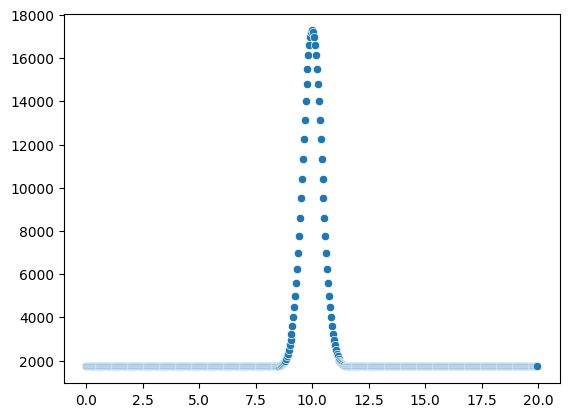

In [65]:
sns.scatterplot(y = gauss_R, x = t/86400)

In [66]:
A = 4629284 #springshed area 
n =.01 #effective porosity
d = 10 # m 
V_l = A * d * n#m^3
S_max = .3 #m
S_0 = 0.3
k = 1 #1 / d 
eta = 0.3
alpha_l = 0.1 #1 /d 
alpha_h = 0.5 #1 /d 

In [67]:
n_days = 100
# steady_state_R = np.ones(n_days) * baseflow / A * 86400 # m / d 
steady_state_R = np.ones(n_days) * baseflow * 86400 # m3 / d
steady_state_t = np.arange(0, n_days)

In [68]:
ss_R_df = pd.DataFrame({'R [m3/d]' : steady_state_R, 'T [d]' : steady_state_t})
ss_R_df.to_csv('conduit_geometry_test/input_data/baseflow_high_eta.csv', index = False)

In [69]:
ss = lr.linear_reservoir_model(steady_state_R * (1-eta), steady_state_R * eta, steady_state_t, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = 0, dt_unit = 'D')
# ss = lr.full_model(steady_state_R , np.zeros(n_days), steady_state_t/86400, A = A, eta = eta, V_l = V_l, S_max = S_max, S_0 = S_0, k = k, n_l = eta, alpha_l = alpha_l, alpha_h = alpha_h, dt_unit = 'D')

No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='Q_l [V/T]'>

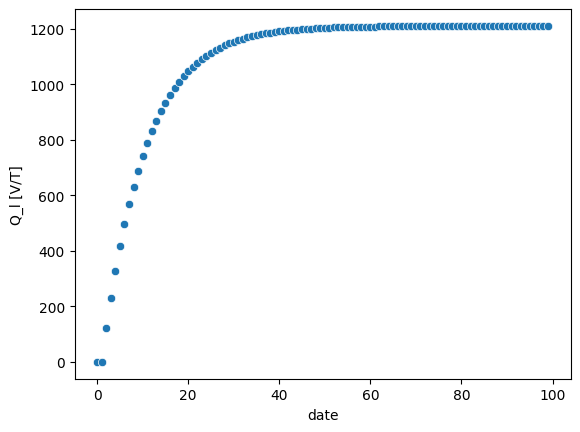

In [70]:
sns.scatterplot(ss, x = 'date', y = 'Q_l [V/T]')


In [87]:
ss_R = np.ones(int(20 * 86400/dt)) * baseflow * 86400 # m3 / d

double_pulse = np.concatenate([gauss_R, gauss_R, ss_R])

In [95]:
V_l0 = ss['V_l [V]'].iloc[-1] #initial V_l 
t = np.arange(0, double_pulse.shape[0] * dt, dt) # in seconds
pulse = lr.linear_reservoir_model(double_pulse * (1-eta), double_pulse * eta, t / 86400, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = V_l0, dt_unit = 'D')


No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='Q_l [V/T]'>

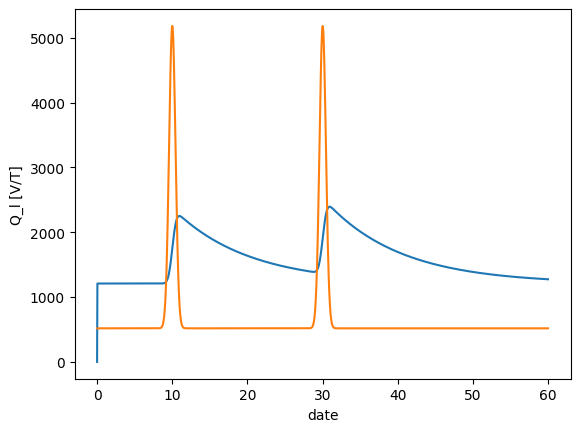

In [96]:
sns.lineplot(pulse, x = 'date', y = 'Q_l [V/T]')
sns.lineplot(pulse, x = 'date', y = 'R_h [V/T]')

In [103]:
ms = pulse.copy()
ms['time'] = ms['date'] * 86400
ms = ms[['time', 'Q_l [V/T]', 'R_h [V/T]']]
ms['R_l [V/T]'] = ms['Q_l [V/T]'] 
ms[['R_l [V/T]', 'R_h [V/T]']] = ms[['R_l [V/T]', 'R_h [V/T]']] / 86400
ms.loc[1:][['time', 'R_l [V/T]', 'R_h [V/T]']].to_csv('conduit_geometry_test/input_data/double_gaussian.csv', index = False)

In [55]:
pulse = pd.read_csv("conduit_geometry_test/input_data/gaussian_pulse_high_eta.csv")

In [14]:
pulse['dV'] = (pulse['V_l [V]'] + pulse['V_h [V]']).diff()
pulse['dV_expected'] = (pulse['R_l [V/T]'] + pulse['R_h [V/T]'] - pulse['Q_h [V/T]']) * pulse['date'].diff()
pulse['dV_error'] = pulse['dV'] - pulse['dV_expected']
pulse['dV_error_rel'] = pulse.dV_error/pulse.dV_expected

Text(0.5, 1.0, 'Linear reservoir recharge partitioning')

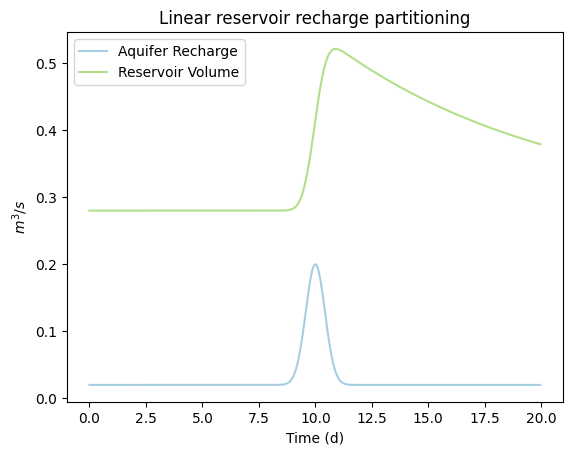

In [107]:
colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}

sns.lineplot(x =pulse.date, y =  pulse['R_l [V/T]']/86400 + pulse['R_h [V/T]']/86400, color = colors['precip'], label = 'Aquifer Recharge')

sns.lineplot(pulse, x = 'date', y = pulse['V_l [V]']/86400 +pulse['V_l [V]']/86400 , label = 'Reservoir Volume', color = colors['R_H'])
# sns.lineplot(pulse, x = 'date', y = pulse['Q_l [V/T]']/86400, label = 'Diffuse Conduit Recharge', color = colors['Q_L'])

# sns.lineplot(x = , y =, label = "Aquifer Recharge")
plt.xlabel("Time (d)")
plt.ylabel(r"$m^3/s$")
plt.title("Linear reservoir recharge partitioning")
# sns.lineplot(ss, x = 'date', y = 'R_h [L/T]')

Text(0, 0.5, '$m^3/s$')

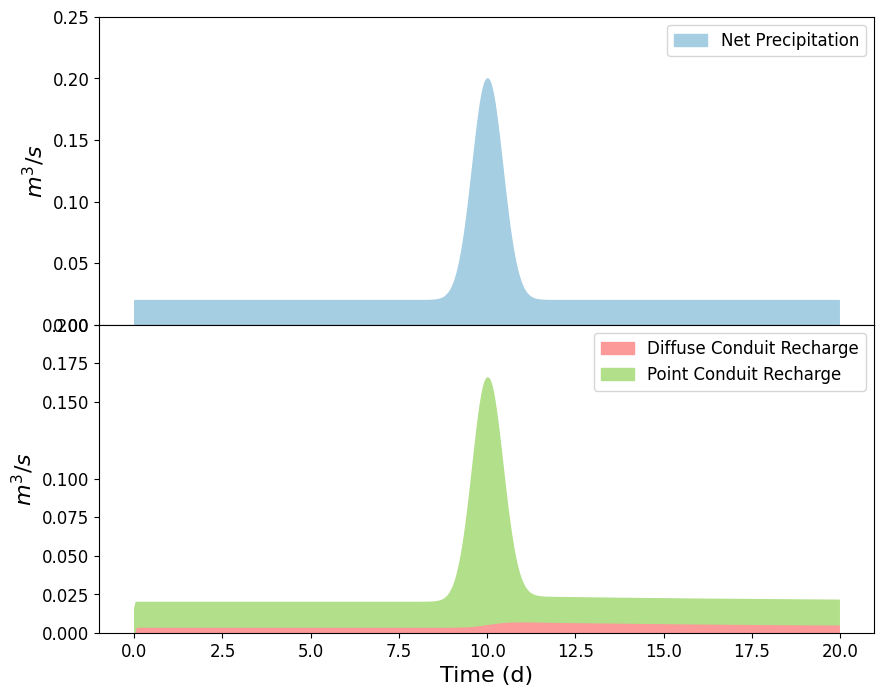

In [59]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 14            # main text size
plt.rcParams['axes.labelsize'] = 16       # axis labels
plt.rcParams['axes.titlesize'] = 18       # title
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Keep text editable in SVG for Inkscape
plt.rcParams['svg.fonttype'] = 'none'

colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}
fig, ax = plt.subplots(2,1, figsize = (10,8), sharex=True, gridspec_kw={'hspace': 0.0})

ax[0].fill_between(x =pulse.date, y1 =  pulse['R_l [V/T]']/86400 + pulse['R_h [V/T]']/86400, color = colors['precip'], label = 'Net Precipitation')
ax[0].set_ylabel(r"$m^3/s$")
ax[0].set_ylim(0,0.25)
ax[0].legend()
# ax[0].set_title("Net Precipitation")
ax[1].yaxis.get_major_ticks()[-1].set_visible(False)   # hide top tick of bottom subplot

ax[1].fill_between(pulse.date, y1 = pulse['Q_l [V/T]']/86400, label = 'Diffuse Conduit Recharge', color = colors['Q_L'])

ax[1].fill_between(pulse.date, y1 = pulse['R_h [V/T]']/86400 + pulse['Q_l [V/T]']/86400, y2 = pulse['Q_l [V/T]']/86400, label = 'Point Conduit Recharge', color = colors['R_H'])
ax[1].legend()
ax[1].set_ylim(0,0.2)
# sns.lineplot(x = , y =, label = "Aquifer Recharge")
plt.xlabel("Time (d)")
plt.ylabel(r"$m^3/s$")
# ax[1].set_title("Conduit Recharge")
# sns.lineplot(ss, x = 'date', y = 'R_h [L/T]')

In [158]:
pulse.to_csv('conduit_geometry_test/input_data/gaussian_pulse_high_eta.csv', index = False)

In [14]:
def write_recharge(network, R_l=None, R_h=None, t_l=None, t_h=None):
    R = {}
    if R_l is not None: 
        if t_l is None:
             return ValueError("Time is None")
        n_diffuse = len(network.diffuse_inlets)
        R_l_per_inlet = R_l / n_diffuse 
        R[network.diffuse_inlets] = {'flow' : R_l_per_inlet, 'time' : t_l}
    if R_h is not None:
        if t_h is None:
            return ValueError("Time is None")
        n_point = len(network.inlets)
        R_h_per_inlet = R_h / n_point 
        R[network.inlets] = {'flow' : R_h_per_inlet, 'time' : t_h}
    #check R values are real
    for inlet, data in R.items():
        if not np.isreal(data['flow']).all():
            raise ValueError(f"Recharge values for inlet {inlet} contain non-real numbers.")
    return R

def write_constant_head_boundary(network, h):
    HB = {network.outlets : {'head' : h}}
    return HB 


In [4]:
pulse = pd.read_csv("conduit_geometry_test/input_data/gaussian_pulse.csv")
ss = pd.read_csv('conduit_geometry_test/input_data/baseflow.csv')
network_dir = 'conduit_geometry_test/networks/anastomotic_simple/'
network_name = 'anastomotic_network_n_1366'
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
network.plot_3D_network(node_color = 'type')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]


# Load Steady State and Write Initial Conditions in Network

In [104]:
network_type = 'anastomotic_simple_clean'
network_name = f'{network_type}/'
run_name = f'spinup/{network_type}'
network_dir = f"conduit_geometry_test/networks/{network_name}"
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
ss_out = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
# input_data = load_pickle(f'conduit_geometry_test/output/{network_name}_spin_up/input_data.pkl')
Q = ss_out['Q']
y = ss_out['y']
t = ss_out['t']
spring = outlet_flow(network, Q)
input = load_pickle(f'conduit_geometry_test/output/{run_name}/input_data.pkl')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]


In [105]:
input

{'nodes':       id              x             y           z      type  d  degree
 0      0  558515.000000  4.867230e+06  396.561836     inlet  1     1.0
 1      1  557954.975539  4.869185e+06  395.553991  junction  1     3.0
 2      2  557918.983064  4.868860e+06  395.497990  junction  1     2.0
 3      3  558161.570793  4.869209e+06  395.920105  junction  1     2.0
 4      4  557915.514704  4.869223e+06  395.483555  junction  1     2.0
 ..   ...            ...           ...         ...       ... ..     ...
 116  116  557988.166388  4.869094e+06  395.616483  junction  1     2.0
 117  117  558074.845245  4.868995e+06  395.766394  junction  1     3.0
 118  118  558073.490705  4.868997e+06  395.766316  junction  1     1.0
 119  119  558250.924683  4.868428e+06  396.080652  junction  1     2.0
 120  120  557952.000000  4.868811e+06  395.559856     inlet  1     1.0
 
 [121 rows x 7 columns],
 'edges':      from_id  to_id            x_0           y_0         z_0            x_1  \
 0         

<Axes: >

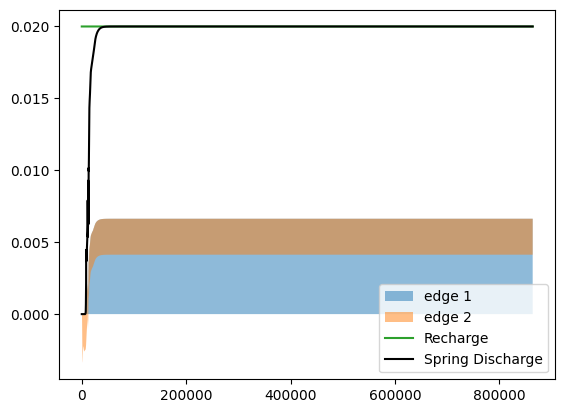

In [36]:
plt.stackplot(
    t,
    Q[:, 44],
    -Q[:, 47],
    labels=["edge 1", "edge 2"],
    alpha = 0.5
)
plt.legend()
sns.lineplot(x = t, y = 0.02, label = 'Recharge')
sns.lineplot(x = t, y = spring[network.outlets[0]], label = 'Spring Discharge', color = 'black')

In [22]:
init_Q = Q[len(t) - 1]
init_h = y[len(t) - 1]


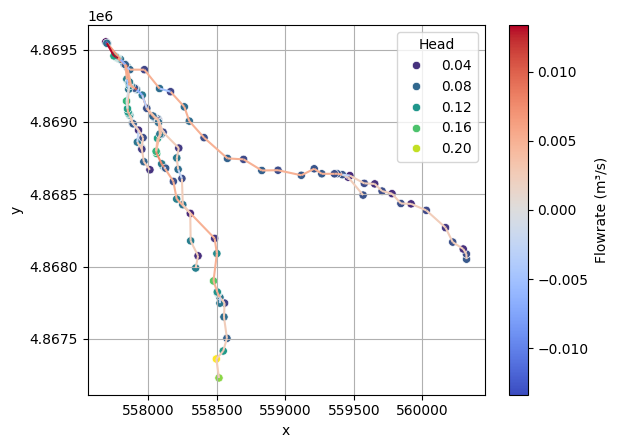

In [23]:
ax = network.plot_network_flow(Q = init_Q, h = init_h)


In [40]:
init_cond = {'initial_flowrate' : init_Q, 'initial_water_depth' : init_h}
write_pickle(f"conduit_geometry_test/input_data/init_conditions/low_slope/{network_type}_IC.pkl", init_cond)

# Load Transient Results

In [109]:
def calculate_recharge(inflow_data):
    total_R = None 
    for inlet, R in inflow_data.items():
        if total_R is None:
            total_R = len(inlet) * R['flow']
        else:
            total_R += len(inlet) * R['flow']
    t_r = inflow_data[list(inflow_data.keys())[0]]['time']
    return total_R, t_r


In [110]:
run_name = 'anastomotic_simple_clean/partitioned'
network_dir = f'conduit_geometry_test/networks/anastomotic_simple_clean'

results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
input_data1= load_pickle(f'conduit_geometry_test/output/{run_name}/input_data.pkl')
network1 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
r1,r_t1 = calculate_recharge(input_data1['inflow_boundary'])
Q1, y1, t1= get_transient_results(results_dir, network_dir)
spring1 = outlet_flow(network1, Q1)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]


In [111]:
network1.calculate_network_volume()

np.float64(7268.911219081892)

In [113]:
ts = 8639
network1.edges['to_h'] = y1[ts,network1.nodes.loc[network1.edges.to_id, 'id']]
network1.edges['from_h'] = y1[ts,network1.nodes.loc[network1.edges.from_id, 'id']]
network1.edges['avg_h'] = (network1.edges['to_h'] + network1.edges['from_h']) / 2
Q_ts = Q1[ts]
network1.edges['Q'] = np.abs(Q_ts[network1.edges.index])

Text(0.5, 1.0, 'Flow Distribution at Peak Flow')

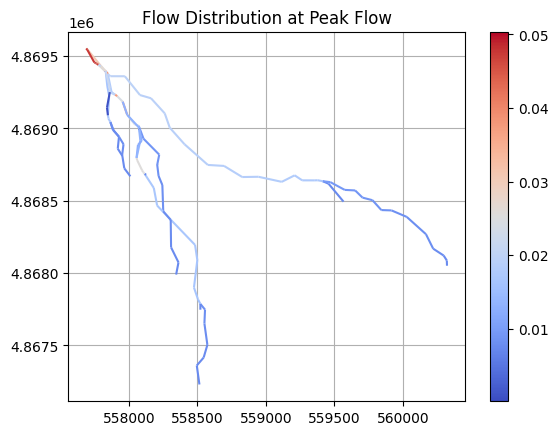

In [ ]:
ax =plot_2D_network(network1.nodes, network1.edges, edge_color = 'Q')
plt.title("Flow Distribution at Peak Flow")
plt.xlim(557500,558500)
plt.ylim(4868300)

In [118]:
outlet_flow(network1, np.array([input_data1['initial_flowrate']]))

{33: array([0.03532985])}

<Axes: xlabel='time', ylabel='R_l [V/T]'>

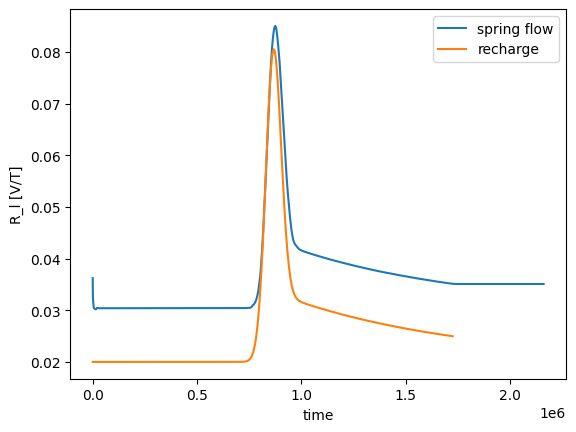

In [162]:
sns.lineplot(y = spring1[network1.outlets[0]], x= t1, label = 'spring flow')
sns.lineplot(y = r1, x = r_t1, label = 'recharge')

In [167]:
Q_df1 = pd.DataFrame({'t' : t1, 'Q' : spring1[network1.outlets[0]]})
Q_df1['t_round'] = Q_df1['t'].round(2)
Q_df1['dt'] = Q_df1['t'].diff()
Q_df1['V'] = (0.5 * (Q_df1['Q'] + Q_df1['Q'].shift()) * Q_df1['dt']).cumsum()

r_df1 = pd.DataFrame({'t' : r_t1, 'R' : r1})
r_df1['dt'] = r_df1['t'].diff()
r_df1['V'] = (0.5 * (r_df1['R'] + r_df1['R'].shift()) * r_df1['dt']).cumsum()

Text(0.5, 1.0, 'Straight Conduit Network, slope = 0.0008')

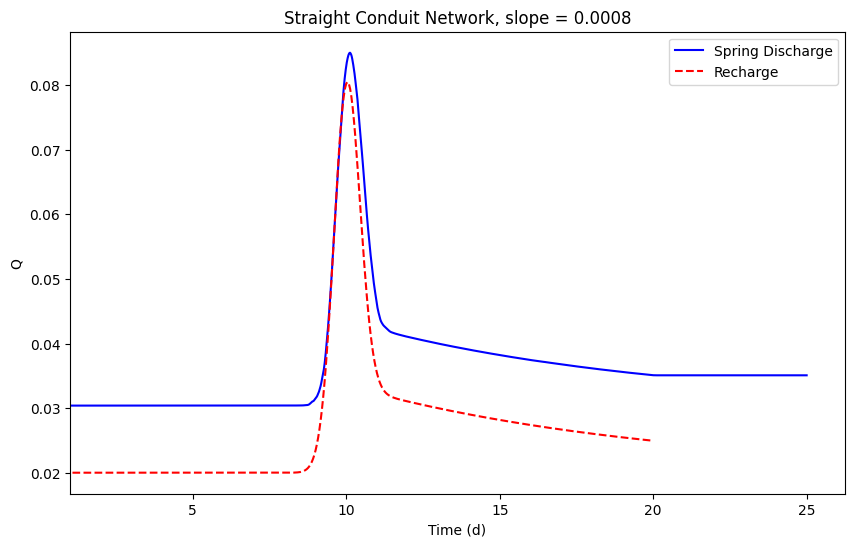

In [168]:
fig, ax = plt.subplots(figsize = (10,6))
sns.lineplot(Q_df1, x = Q_df1.t/86400, y = 'Q', color = 'blue', label = 'Spring Discharge')
sns.lineplot(r_df1, x = r_df1.t/86400, y = 'R', color = 'red', label = 'Recharge', linestyle = '--')
plt.xlabel("Time (d)")
plt.xlim(1)
plt.title("Straight Conduit Network, slope = 0.0008")

In [170]:
spring_Q = spring1[network1.outlets[0]]
peak_idx= np.argmax(spring_Q)
recession_Q = spring_Q[peak_idx:]
recession_t = t1[peak_idx:]
logQ = np.log(recession_Q + 1e-12) # add small value
m, b = np.polyfit(recession_t, logQ, 1)


In [171]:
slopes, t_segments = calculate_recession_coefficients(recession_t, recession_Q)

Text(0.5, 1.0, 'Recession Analysis')

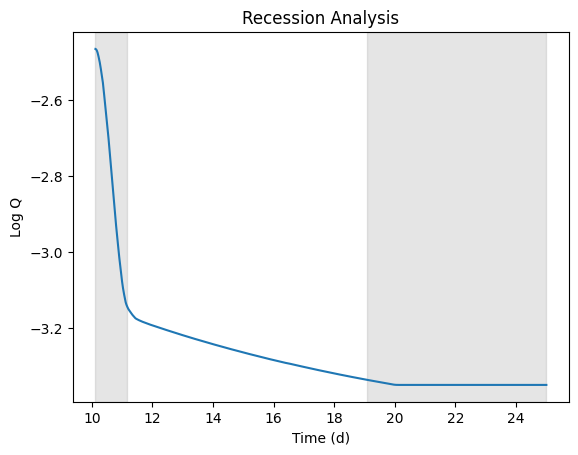

In [182]:
fig, ax = plt.subplots()
sns.lineplot(x = recession_t/86400, y = logQ, ax = ax)
for i in range(len(t_segments) - 1):
    if i % 2 == 0:
        ax.axvspan(t_segments[i]/86400, t_segments[i+1]/86400, color='gray', alpha=0.2)
ax.set_xlabel("Time (d)")
ax.set_ylabel("Log Q")
plt.title("Recession Analysis")

In [189]:
run_name = 'branching_straight_network/partitioned'
network_dir = f'conduit_geometry_test/networks/branching_straight_network'
results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
input_data2 = load_pickle(f'conduit_geometry_test/output/{run_name}/input_data.pkl')
network2 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
r2,r_t2 = calculate_recharge(input_data2['inflow_boundary'])

Q2, y2, t2 = get_transient_results(results_dir, network_dir)
spring2 = outlet_flow(network2, Q2)
coeffs_2, t_segments2 = calculate_recession_coefficients(t2, spring2[network2.outlets[0]])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


In [190]:
network2.calculate_network_volume()

np.float64(6360.798072268418)

In [215]:
ts = 8639
network2.edges['to_h'] = y2[ts,network2.nodes.loc[network2.edges.to_id, 'id']]
network2.edges['from_h'] = y2[ts,network2.nodes.loc[network2.edges.from_id, 'id']]
network2.edges['avg_h'] = (network2.edges['to_h'] + network2.edges['from_h']) / 2

<Axes: >

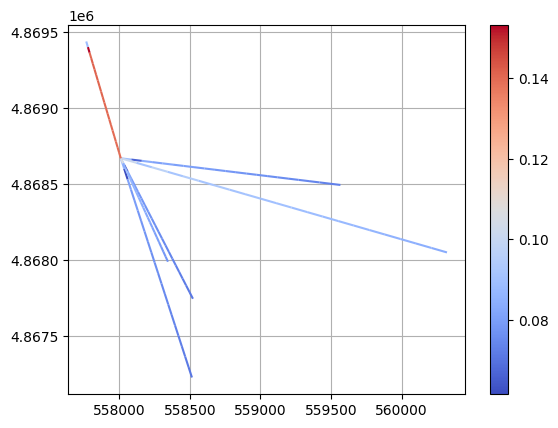

In [216]:
plot_2D_network(network2.nodes, network2.edges, edge_color = 'avg_h')

In [93]:
Q_df2 = pd.DataFrame({'t' : t2, 'Q' : spring2[network2.outlets[0]]})
Q_df2['t_round'] = Q_df2['t'].round(2)
Q_df2['dt'] = Q_df2['t'].diff()
Q_df2['V'] = (0.5 * (Q_df2['Q'] + Q_df2['Q'].shift()) * Q_df2['dt']).cumsum()

r_df2 = pd.DataFrame({'t' : r_t2, 'R' : r1})
r_df2['dt'] = r_df2['t'].diff()
r_df2['V'] = (0.5 * (r_df2['R'] + r_df2['R'].shift()) * r_df2['dt']).cumsum()

Text(0.5, 1.0, 'Straight Conduit Network, slope = 0.008')

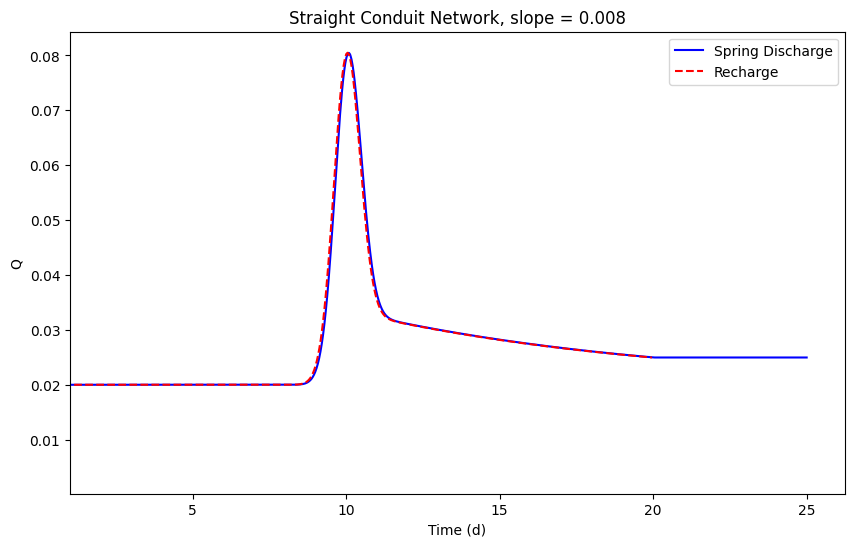

In [94]:
fig, ax = plt.subplots(figsize = (10,6))
sns.lineplot(Q_df2, x = Q_df2.t/86400, y = 'Q', color = 'blue', label = 'Spring Discharge')
sns.lineplot(r_df2, x = r_df2.t/86400, y = 'R', color = 'red', label = 'Recharge', linestyle = '--')
plt.xlabel("Time (d)")
plt.xlim(1)
plt.title("Straight Conduit Network, slope = 0.008")

(1.0, 26.249877147572118)

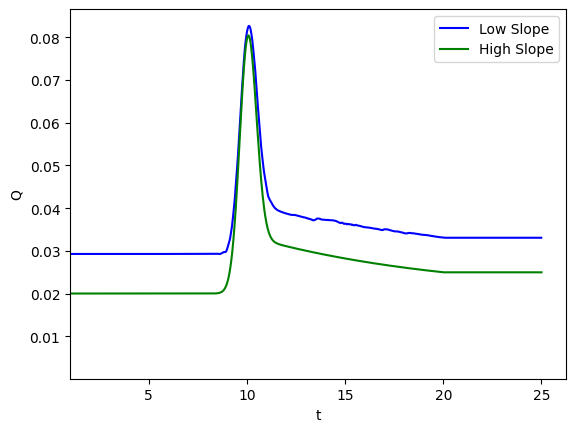

In [95]:
sns.lineplot(Q_df1, x = Q_df1.t/86400, y = 'Q', color = 'blue', label = 'Low Slope')
sns.lineplot(Q_df2, x = Q_df2.t/86400, y = 'Q', color = 'green', label = 'High Slope')
plt.xlim(1,)


In [230]:
run_name = 'low_slope/branching_straight_network/point'
input_data3 = load_pickle(f'conduit_geometry_test/output/{run_name}/input_data.pkl')
results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
network_dir = f'conduit_geometry_test/networks/branching_straight_network'
network3 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
r3,r_t3 = calculate_recharge(input_data3['inflow_boundary'])

Q3, y3, t3, spring3 = get_transient_results(results_dir, network_dir)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


In [231]:
Q_df3 = pd.DataFrame({'t' : t3, 'Q' : spring3[network3.outlets[0]]})
Q_df3['t_round'] = Q_df3['t'].round(2)
Q_df3['dt'] = Q_df3['t'].diff()
Q_df3['V'] = (0.5 * (Q_df3['Q'] + Q_df3['Q'].shift()) * Q_df3['dt']).cumsum()

r_df3 = pd.DataFrame({'t' : r_t3, 'R' : r3})
r_df3['dt'] = r_df3['t'].diff()
r_df3['V'] = (0.5 * (r_df3['R'] + r_df3['R'].shift()) * r_df3['dt']).cumsum()

Text(0.5, 1.0, 'Branching Network')

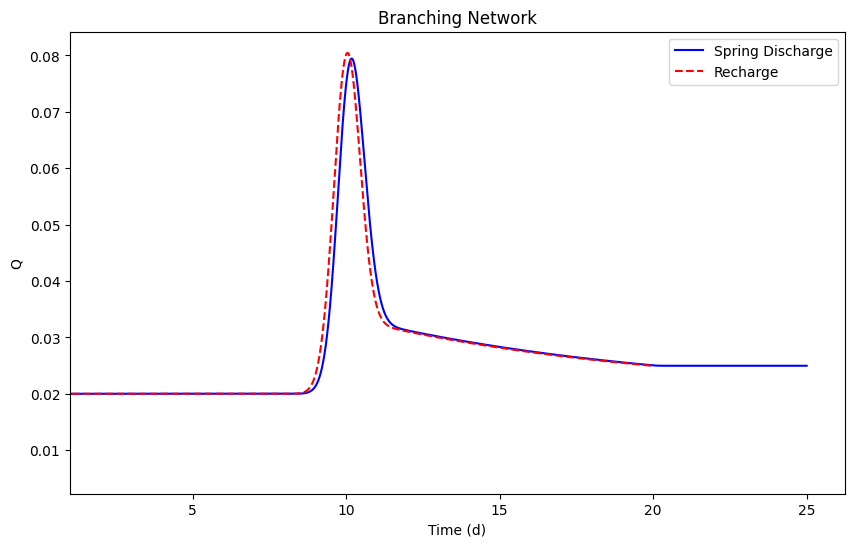

In [232]:
fig, ax = plt.subplots(figsize = (10,6))
sns.lineplot(Q_df3, x = Q_df3.t/86400, y = 'Q', color = 'blue', label = 'Spring Discharge')
sns.lineplot(r_df3, x = r_df3.t/86400, y = 'R', color = 'red', label = 'Recharge', linestyle = '--')
plt.xlabel("Time (d)")
plt.xlim(1)
plt.title("Branching Network")

In [227]:
data = {
        'Straight' : {'Q' : Q1, 't' : t1, 'h' :y1, 'spring' : spring1},

        'Tortuous' : {'Q' : Q2, 't' : t2, 'h' : y2, 'spring' : spring2},

    'Branching' : {'Q' : Q3, 't' : t3, 'h' : y3, 'spring' : spring3}
}
base_case = data['Straight']['spring'][list(data['Straight']['spring'].keys())[0]]

(1.0, 27.0)

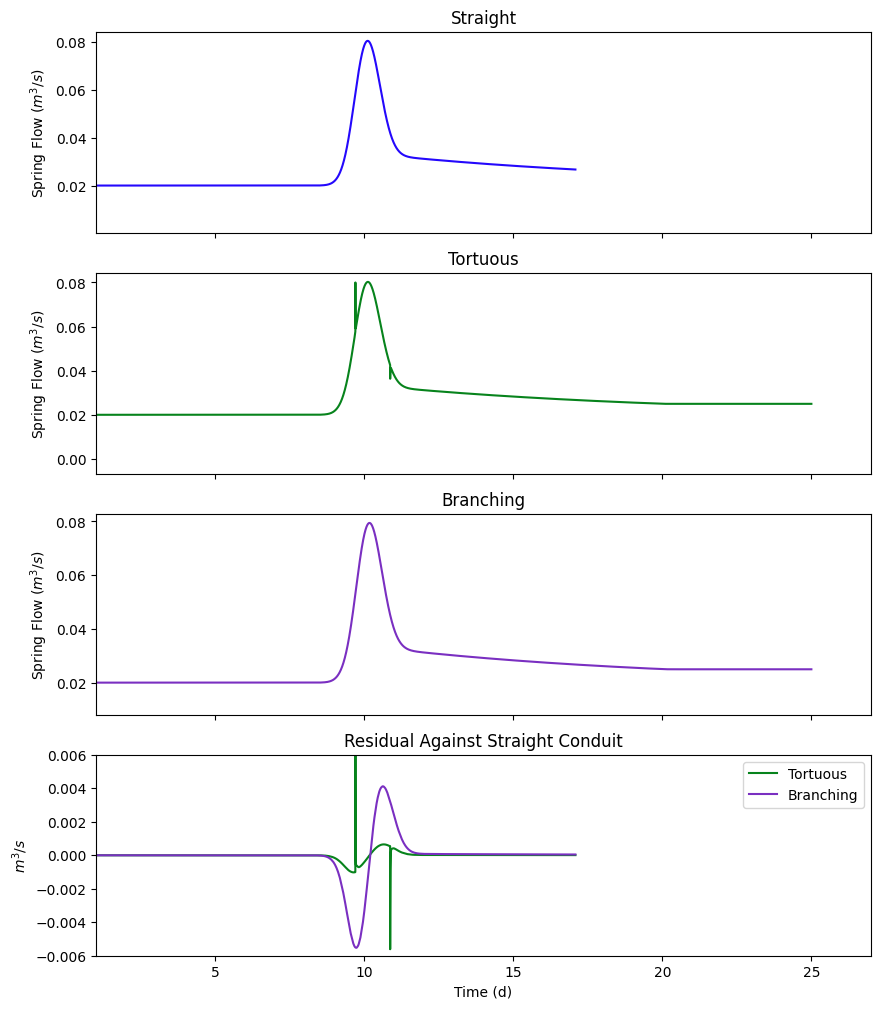

In [229]:
colors =     {'Straight':     "#2408FC",  
               # pastel coral/red
    'Tortuous':     "#07831C",
    'Branching' : "#7A2FC1"} # pastel purple
fig, ax = plt.subplots(len(data.keys())+1, 1, sharex = True, gridspec_kw={'wspace' : 0}, figsize = (10, 12))
i = 0
for name in data.keys():
    spring = data[name]['spring']
    t = data[name]['t']
    for node, Q_spring in spring.items():
        sns.lineplot(x = t/86400, y = Q_spring, color = colors[name], ax = ax[i])
        ax[i].set_title(name)
        # ax[i].set_ylim(0, 0.1)
        ax[i].set_ylabel(r"Spring Flow ($m^3/s$)")
        ax[i].set_xlim(1, 27)
        i+= 1
        if name != 'Straight': #plot residual against base case for non-straight cases
            sns.lineplot( x = t[:len(base_case)]/86400, y = Q_spring[:len(base_case)] - base_case, ax = ax[len(data.keys())], label = f"{name}", color = colors[name])
ax[len(data.keys())].set_xlabel("Time (d)")
ax[len(data.keys())].set_title("Residual Against Straight Conduit")
ax[len(data.keys())].set_ylabel(r"$m^3/s$")
ax[len(data.keys())].set_ylim(-0.006, 0.006)
ax[len(data.keys())].set_xlim(1, 27)


# ax[3].set_xlabel("Time (d)")
# ax[1].set_ylabel("Spring Flow (m3/s)")
# ax[0].set_title("Spring Discharge")
# sns.lineplot(x = sc_t/86400, y=pk_spring[pk_network.outlets[0]]-sc_spring[sc_network.outlets[0]], ax = ax[3], label = 'Tortuous')
# sns.lineplot(x = sc_t/86400, y=b_spring[b_network.outlets[0]]-sc_spring[sc_network.outlets[0]], ax = ax[3], label = 'Branching')
# ax[3].set_title("Residual Against Base Case")
# # for nodes, r_i in r.items():
# #     sns.lineplot(x = r_i['time'], y = r_i['flow'] * len(nodes), label = 'diffuse R' if len(nodes) > 1 else 'point R')
# plt.tight_layout()

## Compare Recharge Conditions

In [85]:
network_name = 'slope_0008'

In [86]:
run_name = f'{network_name}/diffuse_only'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
network = ok.load_network_data(f'conduit_geometry_test/networks/{network_name}/nodes.csv', f'conduit_geometry_test/networks/{network_name}/edges.csv')
network.extract_diffuse_inlets()
Q1 = results['Q']
y1 = results['y']
t1 = results['t']
spring1 = get_outlet_Q(Q1, network.outlets, network.edges)



In [87]:
run_name = f'{network_name}_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
t = results['t']
spring = get_outlet_Q(Q, network.outlets, network.edges)

FileNotFoundError: [Errno 2] No such file or directory: 'conduit_geometry_test/output/slope_0008_gauss/results_arrays.npz'

In [88]:
run_name = f'{network_name}/point_only'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
network = ok.load_network_data(f'conduit_geometry_test/networks/{network_name}/nodes.csv', f'conduit_geometry_test/networks/{network_name}/edges.csv')
network.extract_diffuse_inlets()
Q2 = results['Q']
y2= results['y']
t2 = results['t']
spring2 = get_outlet_Q(Q2, network.outlets, network.edges)

In [89]:
data = {
        'Point' : {'Q' : Q2, 't' : t2, 'h' : y2, 'spring' : spring2},

    'Diffuse' : {'Q' : Q1, 't' : t1, 'h' :y1, 'spring' : spring1},
}

In [96]:
t

array([1.00000e+01, 2.00000e+01, 3.00000e+01, ..., 1.47598e+06,
       1.47599e+06, 1.47600e+06])

(1.0, 27.0)

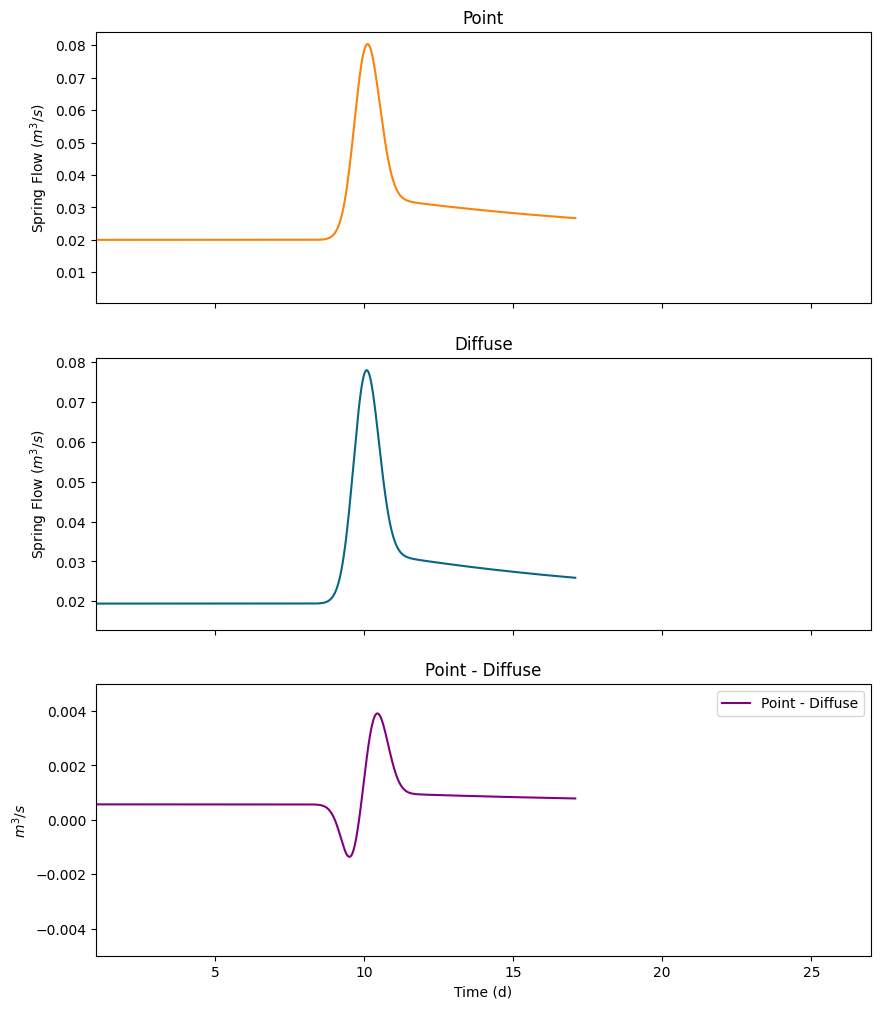

In [90]:
colors =     {'Point':     "#FC8208",  
               # pastel coral/red
    'Diffuse':     "#076683",
}
fig, ax = plt.subplots(len(data.keys())+1, 1, sharex = True, gridspec_kw={'wspace' : 0}, figsize = (10, 12))
i = 0
for name in data.keys():
    spring = data[name]['spring']
    t = data[name]['t']
    for node, Q_spring in spring.items():
        sns.lineplot(x = t/86400, y = Q_spring, color = colors[name], ax = ax[i])
        ax[i].set_title(name)
        # ax[i].set_ylim(0, 0.1)
        ax[i].set_ylabel(r"Spring Flow ($m^3/s$)")
        ax[i].set_xlim(1, 27)
        i+= 1
        # if name != 'Straight': #plot residual against base case for non-straight cases
sns.lineplot( x = t/86400, y = spring2[network.outlets[0]] - spring1[network.outlets[0]], ax = ax[len(data.keys())], label = f"Point - Diffuse", color = 'purple')
ax[len(data.keys())].set_xlabel("Time (d)")
ax[len(data.keys())].set_title("Point - Diffuse")
ax[len(data.keys())].set_ylabel(r"$m^3/s$")
ax[len(data.keys())].set_ylim(-0.005, 0.005)
ax[len(data.keys())].set_xlim(1, 27)


Text(0, 0.5, 'Spring Flow ($m^3/s$)')

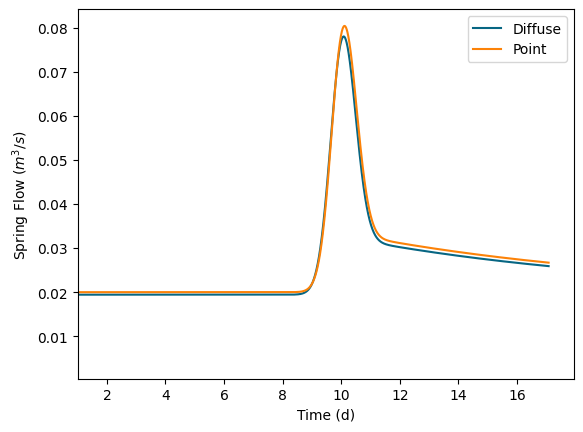

In [98]:
sns.lineplot(x = t1/86400, y =spring1[network.outlets[0]], label = 'Diffuse', color = colors['Diffuse'])
sns.lineplot(x = t2/86400, y = spring2[network.outlets[0]], label = 'Point', color = colors['Point'])
plt.xlabel("Time (d)")
plt.xlim(1,)
plt.ylabel(r"Spring Flow ($m^3/s$)")

# Conduit Network Volume 

In [137]:
network_name = 'high_eta/branching_straight_network_diffuse'
run_name = f'{network_name}'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')

In [138]:
network.calculate_network_volume()

np.float64(6360.798072268418)